In [1]:
# Cell 1: Imports
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking, TimeDistributed 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import random
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")

TensorFlow Version: 2.16.2
Num GPUs Available: 0


In [2]:
# Cell 2: Configuration
PROCESSED_DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'notebooks/steinmetz_data_downloads'))
print(f"Data will be loaded from: {PROCESSED_DATA_DIR}")

TARGET_BRAIN_REGION_X = 'VISp'
TARGET_BRAIN_REGION_Y = 'MOs'

X_TIME_WINDOW_START_POST_EVENT_MS = 0
X_TIME_WINDOW_END_POST_EVENT_MS = 500

Y_TIME_WINDOW_BEFORE_RESPONSE_MS = 250
Y_TIME_WINDOW_AFTER_RESPONSE_MS = 250

N_EPOCHS = 100
BATCH_SIZE = 64
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DENSE_UNITS_REG = 64
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.0001
N_SPLITS_CV = 5
EARLY_STOPPING_PATIENCE = 20

APPLY_PCA_X = False
N_PCA_COMPONENTS_X = None
APPLY_PCA_Y = False 
N_PCA_COMPONENTS_Y = None

APPLY_UPSAMPLING = True

Data will be loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [3]:
# Cell 3: Data Loading
def load_steinmetz_npz_data(data_dir):
    # --- DEBUG BLOCK START ---
    print(f"[DEBUG] data_dir received by function: {data_dir}")
    try:
        print(f"[DEBUG] Contents of data_dir ({data_dir}) according to os.listdir(): {os.listdir(data_dir)}")
    except Exception as e:
        print(f"[DEBUG] Error listing data_dir: {e}")
    debug_path_part0 = os.path.join(data_dir, 'steinmetz_part0.npz')
    print(f"[DEBUG] Checking path: {debug_path_part0}")
    print(f"[DEBUG] os.path.exists(debug_path_part0): {os.path.exists(debug_path_part0)}")
    print(f"[DEBUG] os.path.isfile(debug_path_part0): {os.path.isfile(debug_path_part0)}")
    # --- DEBUG BLOCK END ---
    alldat_list = []
    main_npz_files = [os.path.join(data_dir, f'steinmetz_part{j}.npz') for j in range(3)]

    print(f"Loading main data from {data_dir}:")
    for f_path in main_npz_files:
        f_name = os.path.basename(f_path)
        if not os.path.isfile(f_path): raise FileNotFoundError(f'{f_name} missing from {data_dir}.')
        print(f"  - Loading {f_name}...")
        try:
            data_part = np.load(f_path, allow_pickle=True)
            if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)) and len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                alldat_list.extend(data_part['dat'])
            else: print(f"Warning: 'dat' in {f_name} not as expected.")
        except Exception as e: print(f"Error loading {f_name}: {e}"); raise
    if not alldat_list: raise ValueError("No main data loaded.")
    print(f"Loaded main data for {len(alldat_list)} sessions.")

    lfp_file_path = os.path.join(data_dir, 'steinmetz_lfp.npz')
    if not os.path.isfile(lfp_file_path): raise FileNotFoundError(f'steinmetz_lfp.npz not found in {data_dir}.')
    print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path)}...")
    dat_LFP_list = []
    try:
        dat_LFP_all_sessions_raw = np.load(lfp_file_path, allow_pickle=True)['dat']
        if (isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict)) or \
           (isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict)):
            dat_LFP_list = list(dat_LFP_all_sessions_raw)
        else: raise ValueError("'dat' in LFP not expected format.")
        print(f"Loaded LFP data for {len(dat_LFP_list)} sessions.")
    except Exception as e: raise ValueError(f"Error loading LFP: {e}")

    if len(alldat_list) != len(dat_LFP_list):
        print(f"Warning: Session count mismatch ({len(alldat_list)} vs {len(dat_LFP_list)}).")
        min_sessions = min(len(alldat_list), len(dat_LFP_list))
        if min_sessions == 0: raise ValueError("Zero sessions after alignment.")
        alldat_list, dat_LFP_list = alldat_list[:min_sessions], dat_LFP_list[:min_sessions]
        print(f"Adjusted to {min_sessions} sessions.")
    return alldat_list, dat_LFP_list

alldat, dat_LFP = load_steinmetz_npz_data(PROCESSED_DATA_DIR)

[DEBUG] data_dir received by function: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads
[DEBUG] Contents of data_dir (/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads) according to os.listdir(): ['steinmetz_lfp.npz', 'steinmetz_part0.npz', 'steinmetz_part1.npz', 'steinmetz_part2.npz']
[DEBUG] Checking path: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads/steinmetz_part0.npz
[DEBUG] os.path.exists(debug_path_part0): True
[DEBUG] os.path.isfile(debug_path_part0): True
Loading main data from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Loaded LFP data for 39 sessions.


In [4]:
# Cell 4: Helper Function - Mouse Details
mouse_age_data = { 'Cori': 11, 'Forssmann': 26, 'Hench': 31, 'Lederberg': 15, 'Moniz': 30, 'Muller': 17, 'Radnitz': 20, 'Richards': 26, 'Tatum': 15, 'Theiler': 46 }
YOUNGER_THRESHOLD_WEEKS = 20
def get_mouse_details_by_session(session_idx, session_data_main):
    mouse_name = session_data_main.get('mouse_name', f"MouseUnknown_S{session_idx}")
    mouse_age_weeks = mouse_age_data.get(mouse_name)
    age_category = 'Unknown'
    if mouse_age_weeks is not None: age_category = 'Younger' if mouse_age_weeks <= YOUNGER_THRESHOLD_WEEKS else 'Older'
    return mouse_name, mouse_age_weeks, age_category

In [5]:
# Cell 5: Data Preprocessing (No PCA, multi-channel X, sequence Y - Corrected stim_onset)
all_X_data, all_Y_data, all_session_ids, all_mouse_names, all_age_categories, all_trial_indices_original = [], [], [], [], [], []
print(f"Processing {len(alldat)} sessions...")

for session_idx in range(len(alldat)):
    session_data_main, session_data_lfp = alldat[session_idx], dat_LFP[session_idx]
    mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
    if age_category == 'Unknown': continue
    
    print(f'\n--- Session {session_idx} (Mouse: {mouse_name}, Age: {mouse_age}w, Category: {age_category}) ---')
    if not all(k in session_data_lfp for k in ['lfp', 'brain_area_lfp']) or \
       not all(k in session_data_main for k in ['stim_onset', 'response_time', 'bin_size']):
        print(f'  Skipping: missing essential keys.'); continue

    lfp_all_channels, lfp_brain_areas, dt_lfp_s = session_data_lfp['lfp'], np.array(session_data_lfp['brain_area_lfp']), session_data_main['bin_size']
    if not isinstance(dt_lfp_s, (int, float)) or dt_lfp_s <= 0: print(f"  Skipping: invalid bin_size."); continue
    n_trials_lfp = lfp_all_channels.shape[1]

    response_times = np.asarray(session_data_main['response_time']).squeeze()
    if response_times.ndim == 0: response_times = np.array([response_times.item()])
    n_trials_resp_time = len(response_times)

    # --- Corrected stim_onset handling ---
    stim_onset_times_orig = session_data_main['stim_onset']
    event_times_for_X = np.asarray(stim_onset_times_orig).squeeze() # Handles both scalar and array
    
    if event_times_for_X.ndim > 1: # Should be 0D (scalar) or 1D (n_trials,)
        print(f'  Skipping session {session_idx}: stim_onset has unexpected shape {event_times_for_X.shape}'); continue
    
    event_source_for_X = "stim_onset"
    # --- End of corrected stim_onset handling ---

    # Determine number of trials based on alignment of LFP, responses, response_times
    # and (if array) event_times_for_X
    n_trials_session = min(n_trials_lfp, n_trials_resp_time)
    if event_times_for_X.ndim == 1: # If stim_onset was per-trial array
        n_trials_session = min(n_trials_session, len(event_times_for_X))
    
    if n_trials_session == 0: 
        print(f'  Skipping session {session_idx}: Zero common trials after initial length checks.')
        continue

    # Slice all data streams
    if lfp_all_channels.shape[1] != n_trials_session: lfp_all_channels = lfp_all_channels[:, :n_trials_session, :]
    if event_times_for_X.ndim == 1 and len(event_times_for_X) != n_trials_session: 
        event_times_for_X = event_times_for_X[:n_trials_session]
    if len(response_times) != n_trials_session: response_times = response_times[:n_trials_session]

    print(f"  Using {n_trials_session} trials for session {session_idx}, X aligned to {event_source_for_X}.")

    visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION_X)[0]
    mos_channel_indices = np.where(np.isin(lfp_brain_areas, [TARGET_BRAIN_REGION_Y, 'MOs', 'MOp']))[0]
    if len(visp_channel_indices) == 0 or len(mos_channel_indices) == 0: 
        print(f'  Skipping: {TARGET_BRAIN_REGION_X} or {TARGET_BRAIN_REGION_Y} not found.'); continue
    lfp_visp_all_trials, lfp_mos_all_trials = lfp_all_channels[visp_channel_indices, :, :], lfp_all_channels[mos_channel_indices, :, :]

    x_start_s, x_end_s = X_TIME_WINDOW_START_POST_EVENT_MS/1000.0, X_TIME_WINDOW_END_POST_EVENT_MS/1000.0
    y_before_s, y_after_s = Y_TIME_WINDOW_BEFORE_RESPONSE_MS/1000.0, Y_TIME_WINDOW_AFTER_RESPONSE_MS/1000.0
    
    session_X_list, session_Y_list, session_trials = [], [], []

    for i in range(n_trials_session):
        # Determine the event time for this specific trial for X windowing
        # If event_times_for_X is scalar, it's the fixed offset from trial start (t=0 of LFP)
        # If it's an array, it's the per-trial absolute time
        event_t_x = event_times_for_X if event_times_for_X.ndim == 0 else event_times_for_X[i]
        resp_t = response_times[i]
        
        if np.isnan(event_t_x) or np.isnan(resp_t): continue

        x_window_start_abs_s = event_t_x + x_start_s # e.g., 0.5 + 0 = 0.5s
        x_window_end_abs_s = event_t_x + x_end_s     # e.g., 0.5 + 0.5 = 1.0s
        
        x_start_idx, x_end_idx = int(np.round(x_window_start_abs_s/dt_lfp_s)), int(np.round(x_window_end_abs_s/dt_lfp_s))
        y_start_idx, y_end_idx = int(np.round((resp_t - y_before_s)/dt_lfp_s)), int(np.round((resp_t + y_after_s)/dt_lfp_s))
        
        if not (0 <= x_start_idx < x_end_idx <= lfp_visp_all_trials.shape[2]) or \
           not (0 <= y_start_idx < y_end_idx <= lfp_mos_all_trials.shape[2]): 
            continue
            
        x_trial, y_trial = lfp_visp_all_trials[:, i, x_start_idx:x_end_idx], lfp_mos_all_trials[:, i, y_start_idx:y_end_idx]
        if x_trial.shape[1] == 0 or y_trial.shape[1] == 0: continue
        
        session_X_list.append(x_trial.T)
        session_Y_list.append(y_trial.T)
        session_trials.append(i)

    if not session_X_list: continue

    max_len_x = max(arr.shape[0] for arr in session_X_list)
    X_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant') for arr in session_X_list])

    max_len_y = max(arr.shape[0] for arr in session_Y_list)
    Y_padded_raw = np.array([np.pad(arr, ((0, max_len_y - arr.shape[0]), (0,0)), 'constant') for arr in session_Y_list])
    Y_avg_channels = np.mean(Y_padded_raw, axis=2) if Y_padded_raw.shape[2] > 0 else np.zeros((Y_padded_raw.shape[0], Y_padded_raw.shape[1]))
    Y_sequence_target = Y_avg_channels.reshape(Y_avg_channels.shape[0], Y_avg_channels.shape[1], 1)

    all_X_data.append(X_padded); all_Y_data.append(Y_sequence_target)
    n_valid = X_padded.shape[0]
    all_session_ids.extend([session_idx]*n_valid); all_mouse_names.extend([mouse_name]*n_valid)
    all_age_categories.extend([age_category]*n_valid); all_trial_indices_original.extend(session_trials)
    print(f'  Added {n_valid} trials. X: {X_padded.shape}, Y: {Y_sequence_target.shape}')

if not all_X_data: raise ValueError("No data collected.")
X_combined, Y_combined = np.concatenate(all_X_data), np.concatenate(all_Y_data)
groups, mouse_names_arr, age_categories_arr = np.array(all_session_ids), np.array(all_mouse_names), np.array(all_age_categories)

print(f'\nShapes before scaling - X: {X_combined.shape}, Y: {Y_combined.shape}')

if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
    n_t, n_ts, n_f = X_combined.shape
    X_final = StandardScaler().fit_transform(X_combined.reshape(-1, n_f)).reshape(n_t, n_ts, n_f)
else: 
    print("X_combined empty/unsuitable for scaling.")
    X_final = X_combined
Y_final = Y_combined
print(f'Shapes after scaling - X: {X_final.shape}, Y: {Y_final.shape}')

if age_categories_arr.size > 0:
    cats, cts = np.unique(age_categories_arr, return_counts=True); print('\nTrial counts:')
    [print(f'  {c}: {ct}') for c, ct in zip(cats, cts)]
if X_final.shape[0] > 0: 
    print(f'Total valid trials: {X_final.shape[0]}') 
else: 
    print('Total trials: 0')

Processing 39 sessions...

--- Session 0 (Mouse: Cori, Age: 11w, Category: Younger) ---
  Using 214 trials for session 0, X aligned to stim_onset.
  Added 169 trials. X: (169, 50, 1), Y: (169, 50, 1)

--- Session 1 (Mouse: Cori, Age: 11w, Category: Younger) ---
  Using 251 trials for session 1, X aligned to stim_onset.
  Skipping: VISp or MOs not found.

--- Session 2 (Mouse: Cori, Age: 11w, Category: Younger) ---
  Using 228 trials for session 2, X aligned to stim_onset.
  Skipping: VISp or MOs not found.

--- Session 3 (Mouse: Forssmann, Age: 26w, Category: Older) ---
  Using 249 trials for session 3, X aligned to stim_onset.
  Added 135 trials. X: (135, 50, 1), Y: (135, 50, 1)

--- Session 4 (Mouse: Forssmann, Age: 26w, Category: Older) ---
  Using 254 trials for session 4, X aligned to stim_onset.
  Skipping: VISp or MOs not found.

--- Session 5 (Mouse: Forssmann, Age: 26w, Category: Older) ---
  Using 290 trials for session 5, X aligned to stim_onset.
  Skipping: VISp or MOs not 

In [6]:
# # Cell 5: Data Preprocessing (No PCA, multi-channel X, sequence Y)
# all_X_data, all_Y_data, all_session_ids, all_mouse_names, all_age_categories, all_trial_indices_original = [], [], [], [], [], []
# print(f"Processing {len(alldat)} sessions...")

# for session_idx in range(len(alldat)):
#     session_data_main, session_data_lfp = alldat[session_idx], dat_LFP[session_idx]
#     mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
#     if age_category == 'Unknown': continue
#     print(f'\n--- Session {session_idx} (Mouse: {mouse_name}, Age: {mouse_age}w, Category: {age_category}) ---')
#     if not all(k in session_data_lfp for k in ['lfp', 'brain_area_lfp']) or not all(k in session_data_main for k in ['stim_onset', 'response_time', 'bin_size']):
#         print(f'  Skipping: missing essential keys.'); continue

#     lfp_all_channels, lfp_brain_areas, dt_lfp_s = session_data_lfp['lfp'], np.array(session_data_lfp['brain_area_lfp']), session_data_main['bin_size']
#     if not isinstance(dt_lfp_s, (int, float)) or dt_lfp_s <= 0: print(f"  Skipping: invalid bin_size."); continue
#     n_trials_lfp = lfp_all_channels.shape[1]

#     response_times = np.asarray(session_data_main['response_time']).squeeze(); 
#     if response_times.ndim == 0: response_times = np.array([response_times.item()])
#     n_trials_resp = len(response_times)

#     stim_onset_times = np.asarray(session_data_main['stim_onset']).squeeze(); event_source_for_X = "stim_onset"
#     if stim_onset_times.ndim == 0: stim_onset_times = np.array([stim_onset_times.item()])
#     n_trials_stim = len(stim_onset_times)
#     if not(n_trials_stim > 1 and (n_trials_stim == n_trials_lfp or n_trials_stim == n_trials_resp)):
#         gocue_times = session_data_main.get('gocue'); 
#         if gocue_times is None: continue
#         gocue_times = np.asarray(gocue_times).squeeze(); 
#         if gocue_times.ndim == 0: gocue_times = np.array([gocue_times.item()])
#         n_trials_gocue = len(gocue_times)
#         if not(n_trials_gocue > 1 and (n_trials_gocue == n_trials_lfp or n_trials_gocue == n_trials_resp)): continue
#         event_times_for_X, event_source_for_X = gocue_times, "gocue"
#     else: event_times_for_X = stim_onset_times

#     n_trials_event_X = len(event_times_for_X); n_trials_session = min(n_trials_lfp, n_trials_event_X, n_trials_resp)
#     if n_trials_session == 0: continue

#     if n_trials_lfp != n_trials_session: lfp_all_channels = lfp_all_channels[:, :n_trials_session, :]
#     if n_trials_event_X != n_trials_session: event_times_for_X = event_times_for_X[:n_trials_session]
#     if n_trials_resp != n_trials_session: response_times = response_times[:n_trials_session]

#     visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION_X)[0]
#     mos_channel_indices = np.where(np.isin(lfp_brain_areas, [TARGET_BRAIN_REGION_Y, 'MOs', 'MOp']))[0]
#     if len(visp_channel_indices) == 0 or len(mos_channel_indices) == 0: print(f'  Skipping: target brain region not found.'); continue
#     lfp_visp_all_trials, lfp_mos_all_trials = lfp_all_channels[visp_channel_indices, :, :], lfp_all_channels[mos_channel_indices, :, :]

#     x_start_s, x_end_s = X_TIME_WINDOW_START_POST_EVENT_MS/1000.0, X_TIME_WINDOW_END_POST_EVENT_MS/1000.0
#     y_before_s, y_after_s = Y_TIME_WINDOW_BEFORE_RESPONSE_MS/1000.0, Y_TIME_WINDOW_AFTER_RESPONSE_MS/1000.0
#     session_X_list, session_Y_list, session_trials = [], [], []

#     for i in range(n_trials_session):
#         event_t, resp_t = event_times_for_X[i], response_times[i]
#         if np.isnan(event_t) or np.isnan(resp_t): continue
#         x_start_idx, x_end_idx = int(np.round((event_t + x_start_s)/dt_lfp_s)), int(np.round((event_t + x_end_s)/dt_lfp_s))
#         y_start_idx, y_end_idx = int(np.round((resp_t - y_before_s)/dt_lfp_s)), int(np.round((resp_t + y_after_s)/dt_lfp_s))
#         if not (0 <= x_start_idx < x_end_idx <= lfp_visp_all_trials.shape[2]) or not (0 <= y_start_idx < y_end_idx <= lfp_mos_all_trials.shape[2]): continue
#         x_trial, y_trial = lfp_visp_all_trials[:, i, x_start_idx:x_end_idx], lfp_mos_all_trials[:, i, y_start_idx:y_end_idx]
#         if x_trial.shape[1] == 0 or y_trial.shape[1] == 0: continue
#         session_X_list.append(x_trial.T); session_Y_list.append(y_trial.T); session_trials.append(i)

#     if not session_X_list: continue

#     max_len_x = max(arr.shape[0] for arr in session_X_list)
#     X_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant') for arr in session_X_list])

#     max_len_y = max(arr.shape[0] for arr in session_Y_list)
#     Y_padded_raw = np.array([np.pad(arr, ((0, max_len_y - arr.shape[0]), (0,0)), 'constant') for arr in session_Y_list])
#     Y_avg_channels = np.mean(Y_padded_raw, axis=2) if Y_padded_raw.shape[2] > 0 else np.zeros((Y_padded_raw.shape[0], Y_padded_raw.shape[1]))
#     Y_sequence_target = Y_avg_channels.reshape(Y_avg_channels.shape[0], Y_avg_channels.shape[1], 1) # Reshape for (samples, timesteps, features=1)

#     all_X_data.append(X_padded); all_Y_data.append(Y_sequence_target)
#     n_valid = X_padded.shape[0]
#     all_session_ids.extend([session_idx]*n_valid); all_mouse_names.extend([mouse_name]*n_valid)
#     all_age_categories.extend([age_category]*n_valid); all_trial_indices_original.extend(session_trials)
#     print(f'  Added {n_valid} trials. X: {X_padded.shape}, Y: {Y_sequence_target.shape}')

# if not all_X_data: raise ValueError("No data collected.")
# X_combined, Y_combined = np.concatenate(all_X_data), np.concatenate(all_Y_data)
# groups, mouse_names_arr, age_categories_arr = np.array(all_session_ids), np.array(all_mouse_names), np.array(all_age_categories)
# print(f'\nShapes before scaling - X: {X_combined.shape}, Y: {Y_combined.shape}')

# if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
#     n_t, n_ts, n_f = X_combined.shape
#     X_final = StandardScaler().fit_transform(X_combined.reshape(-1, n_f)).reshape(n_t, n_ts, n_f)
# else: print("X_combined empty/unsuitable for scaling."); X_final = X_combined
# Y_final = Y_combined
# print(f'Shapes after scaling - X: {X_final.shape}, Y: {Y_final.shape}')

# if age_categories_arr.size > 0:
#     cats, cts = np.unique(age_categories_arr, return_counts=True); print('\nTrial counts:'); [print(f'  {c}: {ct}') for c, ct in zip(cats, cts)]

# if X_final.shape[0] > 0: 
#     print(f'Total valid trials: {X_final.shape[0]}') 
# else: 
#     print('Total trials: 0')

In [7]:
# Cell 6: Model Definition (for sequence target)
def create_lstm_model(input_shape_x, output_timesteps, output_features, lstm_units_1, lstm_units_2, dense_units_reg, dropout_rate, learning_rate):
    model = Sequential([
        Input(shape=input_shape_x),
        Masking(mask_value=0.),
        LSTM(lstm_units_1, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units_2, return_sequences=True), # Must return sequences for TimeDistributed
        Dropout(dropout_rate),
        # No intermediate Dense layer, or it also needs to be TimeDistributed or flattened before
        TimeDistributed(Dense(output_features, activation='linear')) # Apply Dense to each timestep
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model



In [8]:
# Cell 7: Model Training (with Upsampling, for sequence target)
if 'X_final' not in globals() or X_final.size == 0 or 'Y_final' not in globals() or Y_final.size == 0 or X_final.shape[0] != Y_final.shape[0]:
    print("Skipping training: X_final/Y_final problematic or trial mismatch.")
else:
    gkf = GroupKFold(n_splits=N_SPLITS_CV)
    fold_val_mse, fold_val_mae, fold_val_r2, fold_histories = [], [], [], []
    all_y_true_val_folds, all_y_pred_val_folds, all_age_categories_val_folds = [], [], []

    input_shape_X_dynamic = (X_final.shape[1], X_final.shape[2])
    output_timesteps_Y_dynamic = Y_final.shape[1] 
    output_features_Y_dynamic = Y_final.shape[2] # Should be 1
    print(f"Using Input Shape: {input_shape_X_dynamic}, Output Shape: ({output_timesteps_Y_dynamic}, {output_features_Y_dynamic}) for training.")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_final, Y_final, groups)):
        print(f'\n--- Fold {fold+1}/{N_SPLITS_CV} ---')
        X_train_orig, X_val = X_final[train_idx], X_final[val_idx]
        Y_train_orig, Y_val = Y_final[train_idx], Y_final[val_idx]
        age_cat_train_orig = age_categories_arr[train_idx]
        age_cat_val = age_categories_arr[val_idx]
        X_train, Y_train, age_cat_train = X_train_orig, Y_train_orig, age_cat_train_orig

        if APPLY_UPSAMPLING:
            print(f'  Original training distribution: {np.unique(age_cat_train_orig, return_counts=True)}')
            younger_idx, older_idx = np.where(age_cat_train_orig == 'Younger')[0], np.where(age_cat_train_orig == 'Older')[0]
            if not (len(younger_idx) > 0 and len(older_idx) > 0): 
                print("  Skipping upsampling: one category missing.")
            elif len(younger_idx) != len(older_idx):
                majority_X, majority_Y, majority_cat_label = (X_train_orig[younger_idx], Y_train_orig[younger_idx], 'Younger') if len(younger_idx) > len(older_idx) else (X_train_orig[older_idx], Y_train_orig[older_idx], 'Older')
                minority_X, minority_Y, minority_cat_label = (X_train_orig[older_idx], Y_train_orig[older_idx], 'Older') if len(younger_idx) > len(older_idx) else (X_train_orig[younger_idx], Y_train_orig[younger_idx], 'Younger')
                n_match = len(majority_X); print(f'  Upsampling {minority_cat_label} from {len(minority_X)} to {n_match}.')
                minority_X_up, minority_Y_up = resample(minority_X, minority_Y, replace=True, n_samples=n_match, random_state=SEED)
                X_train = np.vstack((majority_X, minority_X_up)); Y_train = np.vstack((majority_Y, minority_Y_up))
                age_cat_train = np.array([majority_cat_label]*len(majority_X) + [minority_cat_label]*len(minority_X_up))
                shuffle_idx = np.random.permutation(len(X_train)); X_train, Y_train, age_cat_train = X_train[shuffle_idx], Y_train[shuffle_idx], age_cat_train[shuffle_idx]
                print(f'  New training distribution: {np.unique(age_cat_train, return_counts=True)}')
            else: print("  Training data balanced. No upsampling.")

        print(f'Shapes - X_train: {X_train.shape}, Y_train: {Y_train.shape}, X_val: {X_val.shape}, Y_val: {Y_val.shape}')
        model = create_lstm_model(input_shape_X_dynamic, output_timesteps_Y_dynamic, output_features_Y_dynamic, LSTM_UNITS_1, LSTM_UNITS_2, DENSE_UNITS_REG, DROPOUT_RATE, LEARNING_RATE)
        if fold == 0: model.summary()
        early_stopping = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, verbose=1, restore_best_weights=True)
        history = model.fit(X_train, Y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
        fold_histories.append(history)
        Y_pred_val = model.predict(X_val)
        mse_val = mean_squared_error(Y_val.reshape(-1, output_features_Y_dynamic), Y_pred_val.reshape(-1, output_features_Y_dynamic))
        mae_val = mean_absolute_error(Y_val.reshape(-1, output_features_Y_dynamic), Y_pred_val.reshape(-1, output_features_Y_dynamic))
        r2_val = np.nan
        if len(np.unique(Y_val.flatten())) > 1 and Y_val.size > output_features_Y_dynamic: # Basic check
            r2_val = r2_score(Y_val.reshape(-1, output_features_Y_dynamic), Y_pred_val.reshape(-1, output_features_Y_dynamic), multioutput='variance_weighted')
        else: print(f"  R2 score not computed for Fold {fold+1}.")
        print(f'Fold {fold+1} Val MSE: {mse_val:.4f}, MAE: {mae_val:.4f}, R-squared: {r2_val:.4f}')
        fold_val_mse.append(mse_val); fold_val_mae.append(mae_val); fold_val_r2.append(r2_val)
        all_y_true_val_folds.append(Y_val); all_y_pred_val_folds.append(Y_pred_val); all_age_categories_val_folds.append(age_cat_val)


Using Input Shape: (50, 1), Output Shape: (50, 1) for training.

--- Fold 1/5 ---
  Original training distribution: (array(['Older', 'Younger'], dtype='<U7'), array([ 659, 1122]))
  Upsampling Older from 659 to 1122.
  New training distribution: (array(['Older', 'Younger'], dtype='<U7'), array([1122, 1122]))
Shapes - X_train: (2244, 50, 1), Y_train: (2244, 50, 1), X_val: (367, 50, 1), Y_val: (367, 50, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 172.1585 - mae: 9.4028 - val_loss: 125.8831 - val_mae: 6.8835
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 171.8482 - mae: 9.3952 - val_loss: 125.8412 - val_mae: 6.8801
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 171.6697 - mae: 9.3917 - val_loss: 125.8567 - val_mae: 6.8795
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 171.5970 - mae: 9.3909 - val_loss: 125.8783 - val_mae: 6.8799
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 171.5777 - mae: 9.3908 - val_loss: 125.8775 - val_mae: 6.8800
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 171.5580 - mae: 9.3907 - val_loss: 125.8731 - val_mae: 6.8800
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 171.5342 - mae: 9.3902 - val_loss: 125.8700 - val_mae: 6.8801
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 171.5531 - mae: 9.3907 - val_loss: 125.8619 - val_mae: 6.8801
Epoch 9/100
36/36 ━━━━━━



--- Cross-Validation Summary ---
Avg Val MSE: 173.4619 (std: 77.0325)
Avg Val MAE: 9.0626 (std: 1.9246)
Avg Val R-squared: -0.0044 (std: 0.0087)


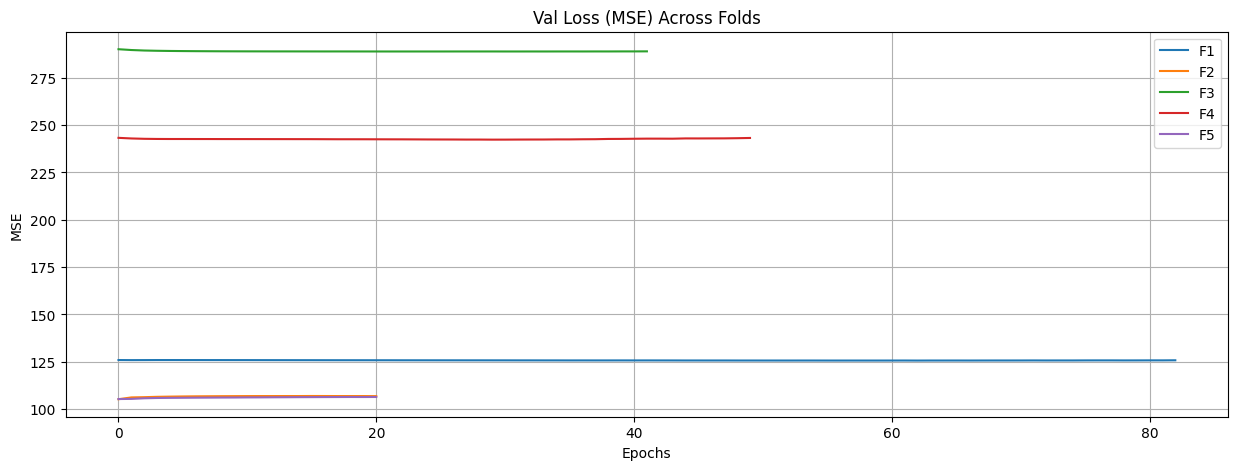


Overall R2 (variance_weighted) on CV data: 0.0039

--- Perf by Age (CV samples) ---
  Younger (N=1489): MSE=203.5665, MAE=9.5294, R2=0.0045
  Older (N=659): MSE=117.0734, MAE=8.3398, R2=-0.0015


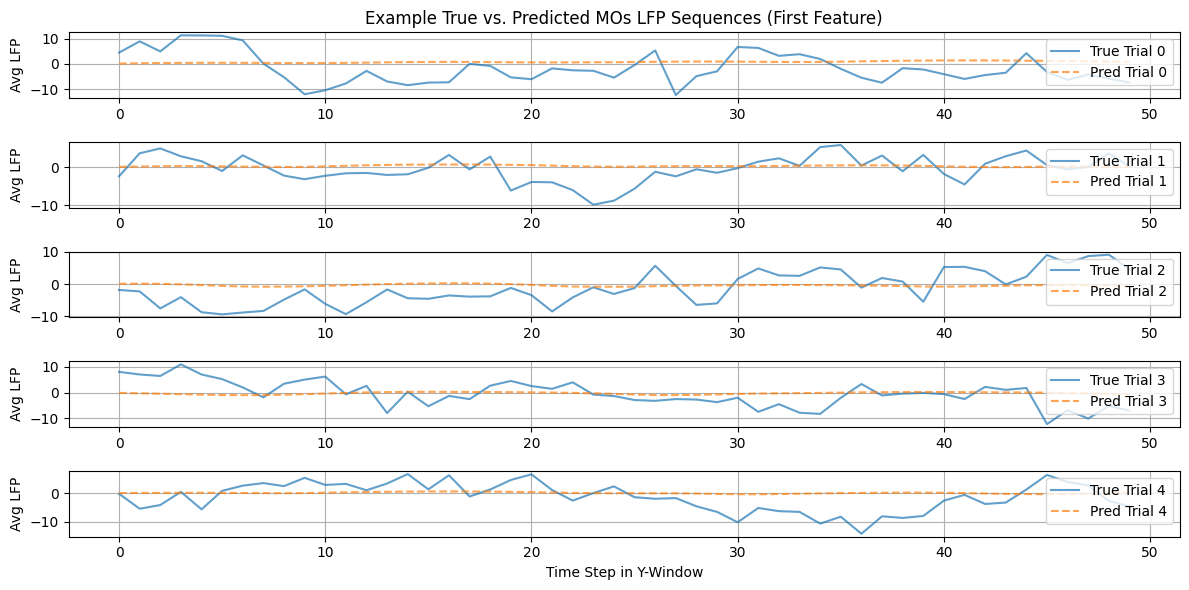


Script analysis section completed.


In [9]:
# Cell 8: Results Aggregation and Age-Based Evaluation (Adapted for sequence target)
if not fold_val_mse: print("Skipping results aggregation: No training metrics.")
else:
    print("--- Cross-Validation Summary ---")
    print(f"Avg Val MSE: {np.nanmean(fold_val_mse):.4f} (std: {np.nanstd(fold_val_mse):.4f})")
    print(f"Avg Val MAE: {np.nanmean(fold_val_mae):.4f} (std: {np.nanstd(fold_val_mae):.4f})")
    print(f"Avg Val R-squared: {np.nanmean(fold_val_r2):.4f} (std: {np.nanstd(fold_val_r2):.4f})")
    if fold_histories:
        plt.figure(figsize=(15,5)); [plt.plot(h.history['val_loss'], label=f'F{i+1}') for i,h in enumerate(fold_histories) if h and 'val_loss' in h.history]
        plt.title('Val Loss (MSE) Across Folds'); plt.xlabel('Epochs'); plt.ylabel('MSE'); plt.legend(); plt.grid(True); plt.show()

    if all_y_true_val_folds:
        Y_true_all_cv, Y_pred_all_cv, age_cat_all_cv = np.concatenate(all_y_true_val_folds), np.concatenate(all_y_pred_val_folds), np.concatenate(all_age_categories_val_folds)
        if Y_true_all_cv.size > Y_true_all_cv.shape[-1] and len(np.unique(Y_true_all_cv.flatten())) > 1: # Check for variance & sufficient samples
            overall_r2 = r2_score(Y_true_all_cv.reshape(-1, Y_true_all_cv.shape[-1]), Y_pred_all_cv.reshape(-1, Y_pred_all_cv.shape[-1]), multioutput='variance_weighted')
            print(f'\nOverall R2 (variance_weighted) on CV data: {overall_r2:.4f}')
        else: print(f'\nOverall R2 not computed.')
        print("--- Perf by Age (CV samples) ---")
        for cat in ['Younger', 'Older']:
            idx = (age_cat_all_cv == cat); 
            if not np.any(idx): print(f'  {cat}: No samples'); continue
            yt, yp = Y_true_all_cv[idx], Y_pred_all_cv[idx]
            if len(yt) > 1 and len(np.unique(yt.flatten())) > 1:
                mse, mae, r2 = mean_squared_error(yt.reshape(-1, yt.shape[-1]), yp.reshape(-1, yp.shape[-1])), mean_absolute_error(yt.reshape(-1, yt.shape[-1]), yp.reshape(-1, yp.shape[-1])), r2_score(yt.reshape(-1, yt.shape[-1]), yp.reshape(-1, yp.shape[-1]), multioutput='variance_weighted')
                print(f'  {cat} (N={len(yt)}): MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}')
            elif len(yt) > 0: print(f'  {cat} (N={len(yt)}): MSE={mean_squared_error(yt.reshape(-1, yt.shape[-1]), yp.reshape(-1, yp.shape[-1])):.4f}, MAE={mean_absolute_error(yt.reshape(-1, yt.shape[-1]), yp.reshape(-1, yp.shape[-1])):.4f}, R2=N/A')
            else: print(f'  {cat}: No samples.')
        if Y_true_all_cv.shape[0] > 0:
            plt.figure(figsize=(12,6)); n_plot_trials = min(5, Y_true_all_cv.shape[0]); n_timesteps_plot = Y_true_all_cv.shape[1]
            for i in range(n_plot_trials):
                plt.subplot(n_plot_trials, 1, i+1)
                plt.plot(Y_true_all_cv[i, :, 0], label=f'True Trial {i}', alpha=0.7)
                plt.plot(Y_pred_all_cv[i, :, 0], label=f'Pred Trial {i}', linestyle='--', alpha=0.7)
                if i == 0: plt.title('Example True vs. Predicted MOs LFP Sequences (First Feature)')
                if i == n_plot_trials -1 : plt.xlabel('Time Step in Y-Window')
                plt.ylabel('Avg LFP'); plt.legend(loc='upper right'); plt.grid(True)
            plt.tight_layout(); plt.show()
print("\nScript analysis section completed.")